# Live PSD horizon: numerical boundaries

This diagnostic compares the original 1.4 + 1.4 solar-mass, SNR-8 horizon with
JAX using identical PSD samples. Default JAX and both complete native control
routes match the original scalar bytes for the two recorded CPU examples.
Separate examples explain the original frequency grid, amplitude precision,
and cumulative-sum rounding. These are controlled changes to the calculation,
not discrepancies attributed to the default JAX implementation.

## Goal

Validate the horizon calculation independently of waveform generation and
search triggers. Run top to bottom with PyCBC, JAX, NumPy, pandas, and Matplotlib.
Inputs are generated here; no frame files or template bank are required.
Recorded agreement is specific to these inputs, library versions, and device.


In [1]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import math
import platform
import sys
from importlib.metadata import version

import jax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import pycbc
from pycbc import scheme
from pycbc.strain.strain_jax import psd_horizon_distance_jax
from pycbc.types import FrequencySeries
from pycbc.waveform.spa_tmplt import (
    spa_amplitude_factor, spa_distance, spa_tmplt_end,
    spa_tmplt_norm, spa_tmplt_precondition,
)

jax.config.update("jax_enable_x64", True)

def show_table(frame, formats=None):
    formatters = {column: pattern.format
                  for column, pattern in (formats or {}).items()}
    display({"text/html": frame.style.format(formats or {}).to_html(),
             "text/plain": frame.to_string(index=False, formatters=formatters)},
            raw=True)

show_table(pd.Series({
    "Python": sys.version.split()[0],
    "PyCBC": version("PyCBC"),
    "NumPy": np.__version__,
    "JAX": jax.__version__,
    "jaxlib": version("jaxlib"),
    "device": jax.devices("cpu")[0].device_kind,
    "architecture": platform.machine(),
}).rename_axis("component").reset_index(name="Recorded environment"))

length, delta_f, cutoff = 2049, 1.0, 20.25
samples = np.exp(np.random.default_rng(834).uniform(-3, 3, length))
kmin = int(cutoff / delta_f)
kend = int(spa_tmplt_end(mass1=1.4, mass2=1.4) / delta_f)
if kend >= length:
    kend = length - 2
amplitude_squared = spa_amplitude_factor(mass1=1.4, mass2=1.4) ** 2.0

def finish(norm):
    return math.sqrt(norm[kend] * amplitude_squared) / 8 * pycbc.DYN_RANGE_FAC

def norm_from_weighted(weighted):
    norm = np.zeros(length, dtype=np.float64)
    norm[kmin:] = weighted.cumsum() * 4.0 * delta_f
    return norm


,component,Recorded environment
0,Python,3.12.7
1,PyCBC,0.0a9304
2,NumPy,2.5.2
3,JAX,0.11.1
4,jaxlib,0.11.1
5,device,cpu
6,architecture,arm64


## Compare identical inputs

The CPU reference calls the original `spa_distance`. Each JAX call constructs
a fresh PSD with the same bytes. Selectors change only the named boundary;
`psd_horizon` replaces the whole calculation. The combined amplitude, division,
and cumulative-sum controls retain the surrounding JAX calculation.


In [2]:
routes = {
    "default": (),
    "amplitude": ("psd_horizon_amplitude",),
    "division": ("divide",),
    "cumulative sum": ("cumsum",),
    "combined stages": ("psd_horizon_amplitude", "divide", "cumsum"),
    "whole horizon": ("psd_horizon",),
}
originals, rows = {}, []
for dtype in (np.float32, np.float64):
    values = samples.astype(dtype)
    with scheme.CPUScheme():
        psd = FrequencySeries(values, delta_f=delta_f)
        reference = spa_distance(psd, 1.4, 1.4, cutoff) * pycbc.DYN_RANGE_FAC
        norm = spa_tmplt_norm(psd, length, delta_f, cutoff)
        amplitude = spa_tmplt_precondition(length, delta_f).numpy().copy()
    assert np.float64(finish(norm)).tobytes() == np.float64(reference).tobytes()
    originals[dtype] = (values, reference, norm, amplitude)
    for name, operations in routes.items():
        with scheme.JAXScheme("cpu", reference_operations=operations):
            actual = psd_horizon_distance_jax(
                FrequencySeries(values, delta_f=delta_f), cutoff)
        exact = np.float64(actual).tobytes() == np.float64(reference).tobytes()
        if name in ("combined stages", "whole horizon"):
            assert exact
        rows.append({
            "PSD dtype": np.dtype(dtype).name,
            "route": name,
            "horizon (Mpc)": actual,
            "relative difference": (actual - reference) / reference,
            "exact scalar bytes": exact,
        })
show_table(pd.DataFrame(rows), {
    "horizon (Mpc)": "{:.15g}", "relative difference": "{:.3e}"})


,PSD dtype,route,horizon (Mpc),relative difference,exact scalar bytes
0,float32,default,3.00633440010896,0.000e+00,True
1,float32,amplitude,3.00633440010896,0.000e+00,True
2,float32,division,3.00633440010896,0.000e+00,True
3,float32,cumulative sum,3.00633440010896,0.000e+00,True
4,float32,combined stages,3.00633440010896,0.000e+00,True
5,float32,whole horizon,3.00633440010896,0.000e+00,True
6,float64,default,3.00633294717948,0.000e+00,True
7,float64,amplitude,3.00633294717948,0.000e+00,True
8,float64,division,3.00633294717948,0.000e+00,True
9,float64,cumulative sum,3.00633294717948,0.000e+00,True


## Isolate rounding and grid conventions

The original amplitude uses `f = (index + 1) * delta_f` and rounds
`f**(-7/6)` to float32 before squaring, including for a float64 PSD. Its
cutoff index is `int(cutoff / delta_f)`; here 20.25 Hz gives index 20,
whose amplitude is evaluated at 21 Hz.

The first control squares the float64 amplitude before rounding its power to
float32. The second widens only the cumulative sum, then casts back before
the original scaling. The third substitutes the usual zero-based FFT grid.
Each keeps the other inputs and scalar finishing operations fixed.


In [3]:
counterfactuals, curves = [], {}
for dtype, (values, reference, norm, amplitude) in originals.items():
    frequencies = np.arange(1, length + 1, dtype=np.float64) * delta_f
    wide_amplitude = frequencies ** (-7.0 / 6.0)
    original_power = amplitude ** 2
    square_first = (wide_amplitude ** 2).astype(np.float32)
    weighted = original_power[kmin:] / values[kmin:]
    assert np.array_equal(norm_from_weighted(weighted), norm)
    wide_sum = weighted.cumsum(dtype=np.float64).astype(weighted.dtype)
    accumulated_norm = np.zeros(length, dtype=np.float64)
    accumulated_norm[kmin:] = wide_sum * 4.0 * delta_f
    zero_grid = np.arange(kmin, length, dtype=np.float64) * delta_f
    zero_amplitude = (zero_grid ** (-7.0 / 6.0)).astype(np.float32)
    controls = {
        "square before float32 amplitude rounding": norm_from_weighted(
            square_first[kmin:] / values[kmin:]),
        "float64 sum then cast": accumulated_norm,
        "zero-based FFT amplitude grid": norm_from_weighted(
            zero_amplitude ** 2 / values[kmin:]),
    }
    for name, alternate in controls.items():
        distance = finish(alternate)
        counterfactuals.append({
            "PSD dtype": np.dtype(dtype).name,
            "controlled change": name,
            "relative horizon change": distance / reference - 1,
            "changed cumulative bins": np.count_nonzero(alternate != norm),
        })
    if dtype is np.float32:
        curves = {"original": norm, "wide sum": accumulated_norm}

show_table(pd.DataFrame(counterfactuals), {
    "relative horizon change": "{:.3e}"})
changed_power = np.flatnonzero(original_power[kmin:] != square_first[kmin:]) + kmin
assert changed_power.size
index = int(changed_power[0])
show_table(pd.DataFrame({
    "frequency (Hz)": [frequencies[index]],
    "round amplitude, then square": [float(original_power[index])],
    "square, then round power": [float(square_first[index])],
}), {column: "{:.12g}" for column in (
    "frequency (Hz)", "round amplitude, then square", "square, then round power")})


,PSD dtype,controlled change,relative horizon change,changed cumulative bins
0,float32,square before float32 amplitude rounding,0.000e+00,0
1,float32,float64 sum then cast,-4.945e-07,1766
2,float32,zero-based FFT amplitude grid,3.805e-02,2029
3,float64,square before float32 amplitude rounding,4.466e-10,2028
4,float64,float64 sum then cast,0.000e+00,0
5,float64,zero-based FFT amplitude grid,3.805e-02,2029


,frequency (Hz),"round amplitude, then square","square, then round power"
0,22,0.000737361377105,0.000737361435313


## See cumulative rounding

For a float32 PSD, the original quotient and cumulative sum stay float32.
Repeated rounded additions differ from one float64 sum cast at the end.
The plot compares these deliberate policies; it does not plot a default
JAX discrepancy. A float64 PSD promotes the quotient and its accumulation,
so this particular widening control changes nothing for that dtype.


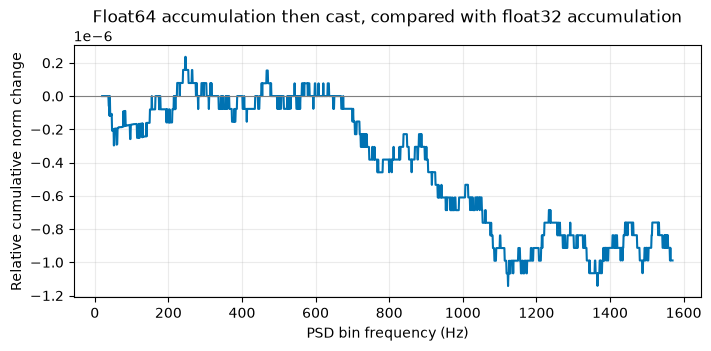

In [4]:
indices = np.arange(kmin, kend + 1)
relative = (curves["wide sum"][indices] / curves["original"][indices] - 1)
fig, ax = plt.subplots(figsize=(7, 3.4), constrained_layout=True)
ax.plot(indices * delta_f, relative, color="#0072B2", linewidth=1.5)
ax.axhline(0, color="0.5", linewidth=.8)
ax.set(xlabel="PSD bin frequency (Hz)",
       ylabel="Relative cumulative norm change",
       title="Float64 accumulation then cast, compared with float32 accumulation")
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
ax.grid(alpha=.25)
plt.show()


## Checks

The combined-stage and whole-stage routes assert exact original scalar bytes
for each PSD dtype. The amplitude example proves that moving a float32 cast
can change individual powers; later accumulation can absorb that difference.
The wider-sum and grid controls show distinct numerical and convention effects.
They should not be substituted when validating the original calculation.

Default conditioning and the horizon integral run on the selected JAX device.
Native controls transfer inputs to original CPU implementations and are slow
diagnostics. They are outside JIT tracing and differentiation. These examples
validate this diagnostic only; they do not establish full-search equivalence.
